In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers, models
from keras.callbacks import ModelCheckpoint

2024-05-08 10:12:25.078768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-08 10:12:25.078873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-08 10:12:25.246665: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
dataset_path ="/kaggle/input/gp-asl-img/american2"

In [3]:
# List all directories in the dataset path, assuming each directory represents a class
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

In [4]:
# Print the list of classes
classes

['n',
 'r',
 'b',
 'i',
 'f',
 'h',
 'e',
 'u',
 'm',
 'x',
 'k',
 'q',
 'y',
 's',
 'g',
 'a',
 'o',
 't',
 'v',
 'z',
 'c',
 'p',
 'l',
 'w',
 'd',
 'j']

In [4]:
data = []
# Iterate over each class directory
for c in classes:
    class_path = os.path.join(dataset_path, c)  # Full path to the class directory
    # Process each image in the class directory
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)  # Full path to the image
        im = cv2.imread(img_path)  # Read the image
        if im is not None:  # Check if the image was correctly loaded
            im = cv2.resize(im, (224, 224))  # Resize the image
            data.append([im, c])  # Append the image and its class label to the data list

In [5]:
X=[]
Y=[]
for x,y in data:
    X.append(x)
    Y.append(y)

In [6]:
x=np.array(X)
y=np.array(Y)
print(x.shape,y.shape)

(12412, 224, 224, 3) (12412,)


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4, stratify=y)

In [8]:
x_train = x_train.astype('float32', copy=False)
x_train /= 255.0
x_test = x_test.astype('float32', copy=False)
x_test /= 255.0


print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(9929, 224, 224, 3) (9929,)
(2483, 224, 224, 3) (2483,)


In [26]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder and transform labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [10]:
model_vgg19=tf.keras.applications.vgg19.VGG19(
    input_shape=None,
    include_top=True,
    weights='imagenet',
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation='softmax'

)

In [11]:
model_vgg19.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
base_input4=model_vgg19.input
base_output4=model_vgg19.layers[-2].output

final_output4 = layers.Dense(240)(base_output4)
final_output4 = layers.Activation('relu')(final_output4)
final_output4 = layers.Dense(128)(final_output4)
final_output4 = layers.Activation('relu')(final_output4)
final_output4 = layers.Dense(64)(final_output4)
final_output4 = layers.Activation('relu')(final_output4)
final_output4 = layers.Dense(37, activation='softmax')(final_output4)

In [13]:
new_model_vgg19 = tf.keras.Model(inputs = base_input4, outputs = final_output4)

In [14]:
new_model_vgg19.compile(loss="sparse_categorical_crossentropy", optimizer = "SGD", metrics = ["accuracy"])

In [15]:
result_V = new_model_vgg19.fit(x_train, y_train_encoded, epochs=10,batch_size=64, validation_data=(x_test, y_test_encoded))

Epoch 1/10


I0000 00:00:1715163453.961229     235 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715163453.985224     235 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1334 - loss: 3.1443

W0000 00:00:1715163642.089715     232 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715163646.697397     233 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715163706.012157     235 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


156/156 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.1343 - loss: 3.1407 - val_accuracy: 0.6404 - val_loss: 1.3172
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8853 - loss: 0.3749 - val_accuracy: 0.9416 - val_loss: 0.3625
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9785 - loss: 0.0991 - val_accuracy: 0.9066 - val_loss: 0.4065
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9900 - loss: 0.0612 - val_accuracy: 0.9980 - val_loss: 0.0069
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9999 - loss: 5.3973e-04 - val_accuracy: 0.9984 - val_loss: 0.0069
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9999 - loss: 4.1924e-04 - val_accuracy: 0.9980 - val_loss: 0.0055
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9998 - loss: 7.8007e-04 - val_accuracy: 0.9956 - val_loss: 0.0154
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 1.0000 - loss: 6.2451e-04 - val

In [40]:
# Access the history to get training and validation accuracy
train_acc = result_V.history['accuracy']  # This might be 'acc' depending on the version of Keras
val_acc = result_V.history['val_accuracy']  # This might be 'val_acc' depending on the version of Keras

# Print the training and validation accuracy
print("Training Accuracy over epochs:")
print(train_acc)
print("Validation Accuracy over epochs:")
print(val_acc)



Training Accuracy over epochs:
[0.2747507393360138, 0.9531674981117249, 0.9787490963935852, 0.9969785213470459, 0.999798595905304, 0.999798595905304, 0.9995971322059631, 1.0, 1.0, 1.0]
Validation Accuracy over epochs:
[0.6403543949127197, 0.941602885723114, 0.9065646529197693, 0.9979863166809082, 0.9983890652656555, 0.9979863166809082, 0.9955698847770691, 0.9991945028305054, 0.9983890652656555, 0.9983890652656555]


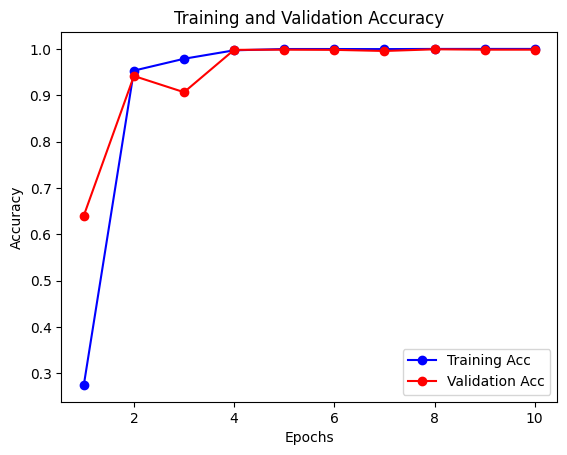

In [39]:
# Optionally, plot the training and validation accuracy
import matplotlib.pyplot as plt

epochs = range(1, 11)  # Number of epochs
plt.plot(epochs, train_acc, 'bo-', label='Training Acc')
plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step


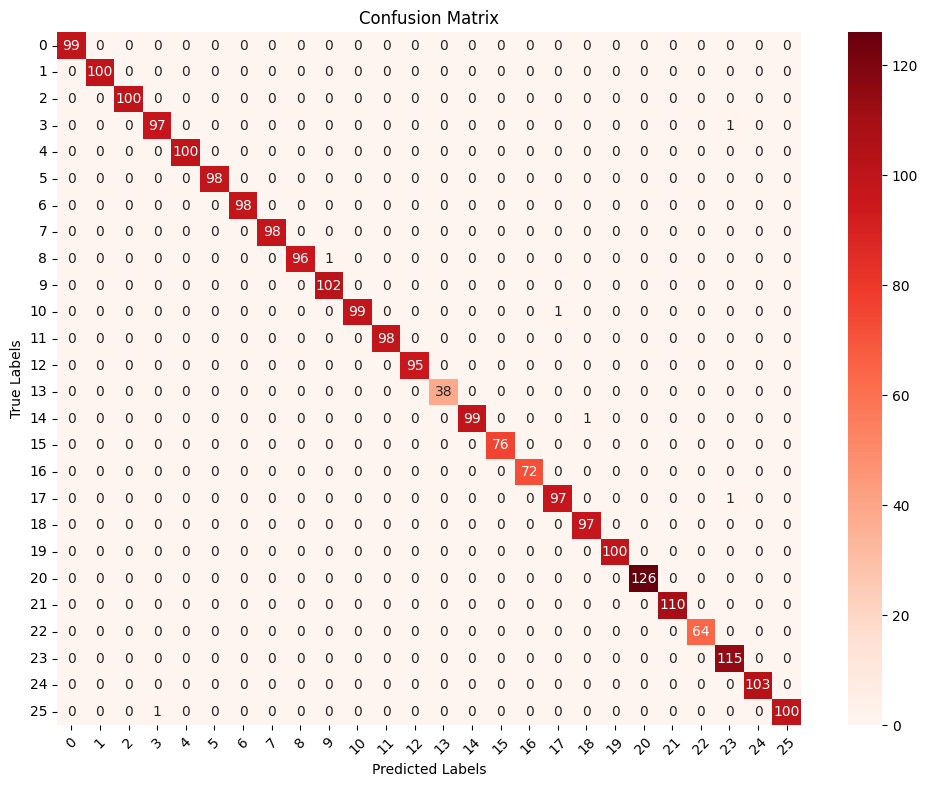

In [35]:
import numpy as np

# Assuming that your model outputs probabilities for each class
# Convert these probabilities to class labels
predictions = new_model_vgg19.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)  # Get the index of the max probability

# Now, generate the confusion matrix with these labels
conf_matrix = confusion_matrix(y_test, predicted_labels)

# Plotting the confusion matrix
plt.figure(figsize=(12, 9))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [36]:
report = classification_report(y_test, predicted_labels, target_names=classes)
print(report)

              precision    recall  f1-score   support

           n       1.00      1.00      1.00        99
           r       1.00      1.00      1.00       100
           b       1.00      1.00      1.00       100
           i       0.99      0.99      0.99        98
           f       1.00      1.00      1.00       100
           h       1.00      1.00      1.00        98
           e       1.00      1.00      1.00        98
           u       1.00      1.00      1.00        98
           m       1.00      0.99      0.99        97
           x       0.99      1.00      1.00       102
           k       1.00      0.99      0.99       100
           q       1.00      1.00      1.00        98
           y       1.00      1.00      1.00        95
           s       1.00      1.00      1.00        38
           g       1.00      0.99      0.99       100
           a       1.00      1.00      1.00        76
           o       1.00      1.00      1.00        72
           t       0.99    

In [42]:
new_model_vgg19.save("new_model_vgg19.h5")

In [41]:
import numpy as np

# Predict the outputs for the entire test set
predictions = new_model_vgg19.predict(x_test)

# Convert probabilities to class labels if your model outputs probabilities
predicted_labels = np.argmax(predictions, axis=1)

# Assuming y_test_encoded is already in the form of class indices
# If y_test_encoded is one-hot encoded, convert it back to class indices
if y_test_encoded.ndim > 1:
    true_labels = np.argmax(y_test_encoded, axis=1)
else:
    true_labels = y_test_encoded

# Calculate the number of correct and incorrect predictions
correct_predictions = np.sum(predicted_labels == true_labels)
incorrect_predictions = np.sum(predicted_labels != true_labels)

# Output the results
print("Number of correct predictions:", correct_predictions)
print("Number of incorrect predictions:", incorrect_predictions)


78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step
Number of correct predictions: 2477
Number of incorrect predictions: 6
